In [4]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/content/safi_data.csv"
df = pd.read_csv(DATA_PATH)

df.head(), df.shape

(   key_ID village        interview_date  no_membrs  years_liv  \
 0       1     God  2016-11-17T00:00:00Z          3          4   
 1       1     God  2016-11-17T00:00:00Z          7          9   
 2       3     God  2016-11-17T00:00:00Z         10         15   
 3       4     God  2016-11-17T00:00:00Z          7          6   
 4       5     God  2016-11-17T00:00:00Z          7         40   
 
   respondent_wall_type  rooms memb_assoc affect_conflicts  liv_count  \
 0              muddaub      1        NaN              NaN          1   
 1              muddaub      1        yes             once          3   
 2          burntbricks      1        NaN              NaN          1   
 3          burntbricks      1        NaN              NaN          2   
 4          burntbricks      1        NaN              NaN          4   
 
                                          items_owned  no_meals  \
 0               bicycle;television;solar_panel;table         2   
 1  cow_cart;bicycle;radio;c

In [5]:

missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

,0
affect_conflicts,0.297710
memb_assoc,0.297710
items_owned,0.076336
interview_date,0.000000
key_ID,0.000000
village,0.000000
respondent_wall_type,0.000000
years_liv,0.000000
no_membrs,0.000000
rooms,0.000000


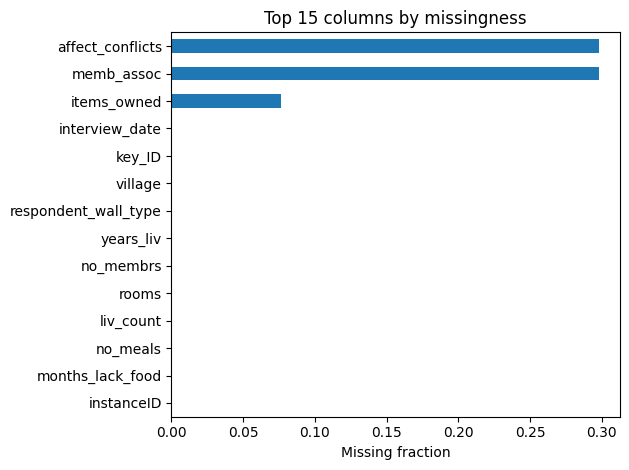

In [6]:

top_n = 15
plt.figure()
missing.head(top_n).iloc[::-1].plot(kind="barh")
plt.xlabel("Missing fraction")
plt.title(f"Top {top_n} columns by missingness")
plt.tight_layout()
plt.show()

In [7]:

import pandas as pd

def parse_list_string(s):
    """
    Safi dataset stores lists as strings like "['a', 'b']".
    This parser tries: literal_eval first; fallback to split on comma/whitespace.
    """
    if pd.isna(s):
        return []
    if isinstance(s, list):
        return s
    s = str(s).strip()

    if s.startswith("[") and s.endswith("]"):
        try:
            import ast
            out = ast.literal_eval(s)
            if isinstance(out, list):
                return [str(x).strip() for x in out if str(x).strip()]
        except Exception:
            pass

    s = s.strip("[]").replace("'", "").replace('"', "")
    if "," in s:
        parts = [p.strip() for p in s.split(",")]
    else:
        parts = [p.strip() for p in s.split()]
    return [p for p in parts if p]

df["months_lack_food_list"] = df["months_lack_food"].apply(parse_list_string)
df["food_shortage_months"] = df["months_lack_food_list"].apply(len)

df["items_owned_list"] = df["items_owned"].apply(parse_list_string)
df["num_items"] = df["items_owned_list"].apply(len)

df[["months_lack_food", "food_shortage_months", "items_owned", "num_items"]].head()

,months_lack_food,food_shortage_months,items_owned,num_items
0,Jan,1,bicycle;television;solar_panel;table,1
1,Jan;Sept;Oct;Nov;Dec,1,cow_cart;bicycle;radio;cow_plough;solar_panel;...,1
2,Jan;Feb;Mar;Oct;Nov;Dec,1,solar_torch,1
3,Sept;Oct;Nov;Dec,1,bicycle;radio;cow_plough;solar_panel;mobile_phone,1
4,Aug;Sept;Oct;Nov,1,motorcyle;radio;cow_plough;mobile_phone,1


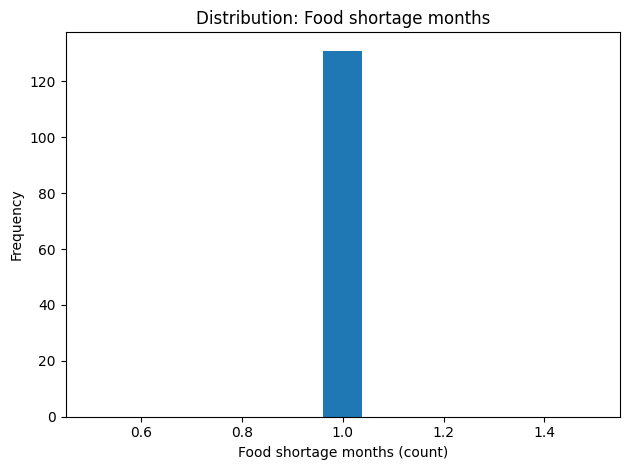

In [8]:

plt.figure()
df["food_shortage_months"].plot(kind="hist", bins=13)
plt.xlabel("Food shortage months (count)")
plt.title("Distribution: Food shortage months")
plt.tight_layout()
plt.show()

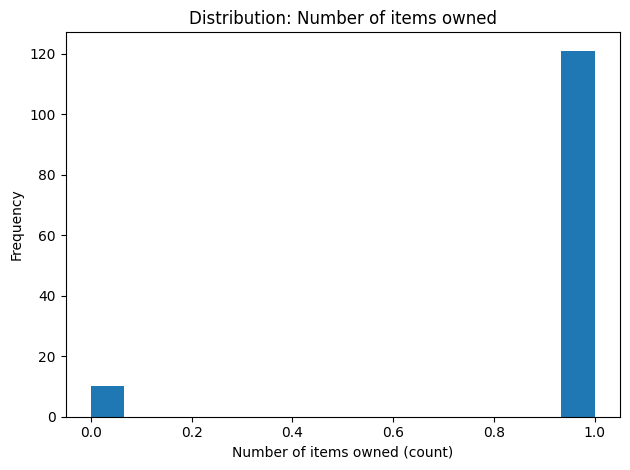

In [9]:
plt.figure()
df["num_items"].plot(kind="hist", bins=15)
plt.xlabel("Number of items owned (count)")
plt.title("Distribution: Number of items owned")
plt.tight_layout()
plt.show()


memb_assoc value counts (including NaN):
memb_assoc
no     59
NaN    39
yes    33
Name: count, dtype: int64

affect_conflicts value counts (including NaN):
affect_conflicts
never         46
NaN           39
more_once     29
frequently     9
once           8
Name: count, dtype: int64


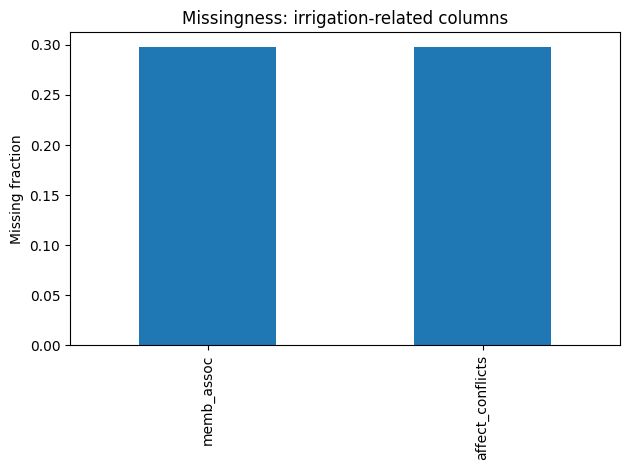

In [10]:

cols = ["memb_assoc", "affect_conflicts"]

for col in cols:
    if col in df.columns:
        print(f"\n{col} value counts (including NaN):")
        print(df[col].value_counts(dropna=False))

miss2 = df[cols].isna().mean()
plt.figure()
miss2.plot(kind="bar")
plt.ylabel("Missing fraction")
plt.title("Missingness: irrigation-related columns")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1787361577.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


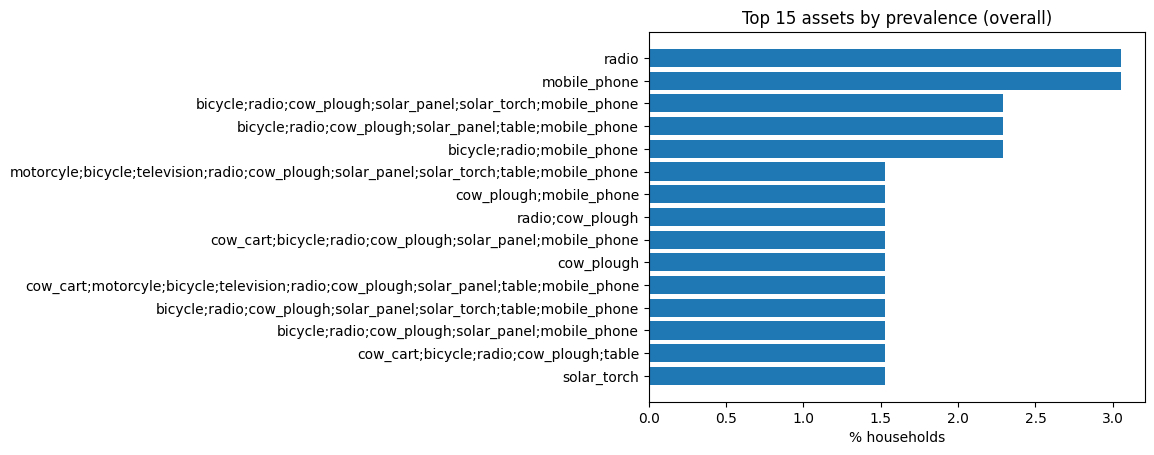

/tmp/ipython-input-1787361577.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


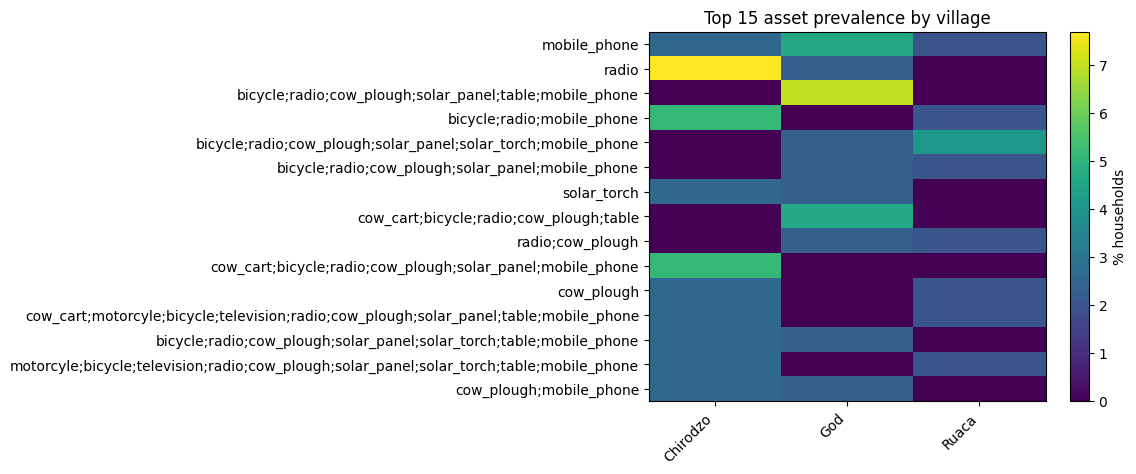

In [11]:

all_items = pd.Series([it for sub in df["items_owned_list"] for it in sub])
item_counts = all_items.value_counts()

topN = 15
top_items = item_counts.head(topN).index.tolist()

prev = pd.DataFrame({
    "item": top_items,
    "pct_households": [
        df["items_owned_list"].apply(lambda lst: it in lst).mean() * 100
        for it in top_items
    ]
}).sort_values("pct_households", ascending=True)

plt.figure()
plt.barh(prev["item"], prev["pct_households"])
plt.xlabel("% households")
plt.title(f"Top {topN} assets by prevalence (overall)")
plt.tight_layout()
plt.show()

villages = sorted(df["village"].dropna().unique().tolist())
mat = np.zeros((len(top_items), len(villages)))

for i, it in enumerate(top_items):
    for j, v in enumerate(villages):
        sub = df[df["village"] == v]
        mat[i, j] = sub["items_owned_list"].apply(lambda lst: it in lst).mean() * 100

plt.figure()
plt.imshow(mat, aspect="auto")
plt.yticks(range(len(top_items)), top_items)
plt.xticks(range(len(villages)), villages, rotation=45, ha="right")
plt.colorbar(label="% households")
plt.title(f"Top {topN} asset prevalence by village")
plt.tight_layout()
plt.show()

In [12]:

num_cols = ["no_membrs", "years_liv", "rooms", "liv_count", "no_meals"]
existing = [c for c in num_cols if c in df.columns]

df[existing].describe().T

,count,mean,std,min,25%,50%,75%,max
no_membrs,131.0,7.190840,3.172270,2.0,5.0,7.0,9.0,19.0
years_liv,131.0,23.053435,16.913041,1.0,12.0,20.0,27.5,96.0
rooms,131.0,1.740458,1.092547,1.0,1.0,1.0,2.0,8.0
liv_count,131.0,2.366412,1.082775,1.0,1.0,2.0,3.0,5.0
no_meals,131.0,2.603053,0.491143,2.0,2.0,3.0,3.0,3.0


<Figure size 640x480 with 0 Axes>

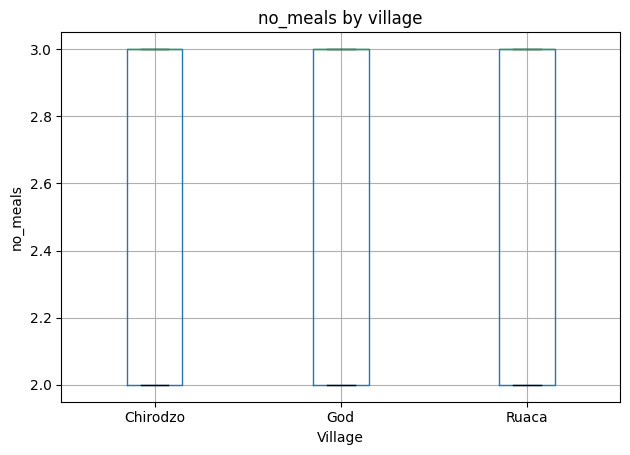

<Figure size 640x480 with 0 Axes>

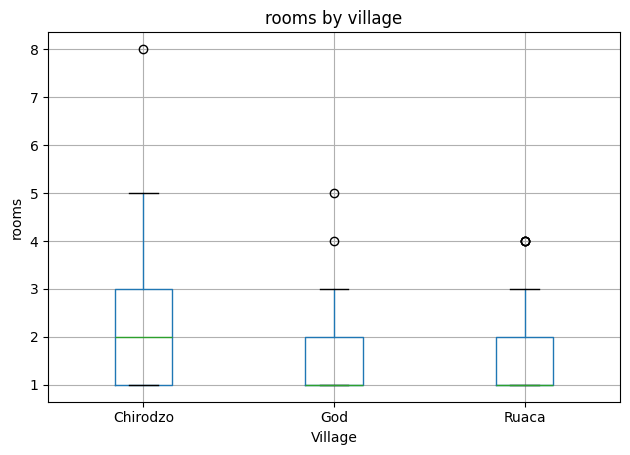

<Figure size 640x480 with 0 Axes>

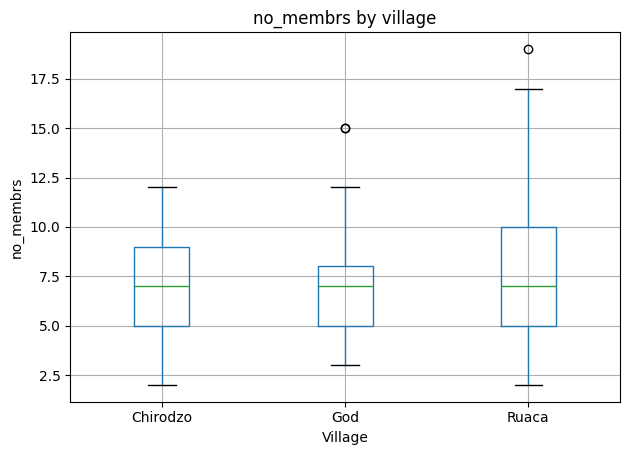

In [13]:

for col in [c for c in ["no_meals", "rooms", "no_membrs"] if c in df.columns]:
    plt.figure()
    df.boxplot(column=col, by="village")
    plt.title(f"{col} by village")
    plt.suptitle("")
    plt.xlabel("Village")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [14]:
#Analysis & Experiments

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

%matplotlib inline

need = ["items_owned_list","months_lack_food_list","num_items","food_shortage_months"]
miss = [c for c in need if c not in df.columns]
if miss:
    raise ValueError(f"Run EDA engineering cell first. Missing: {miss}")

print("df:", df.shape)

df: (131, 18)


<Figure size 1000x400 with 0 Axes>

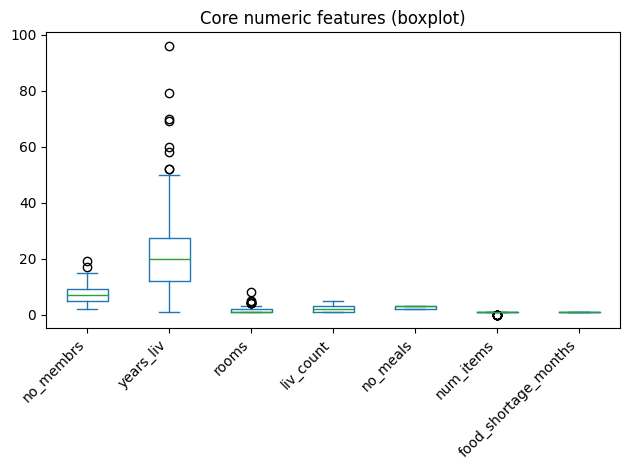

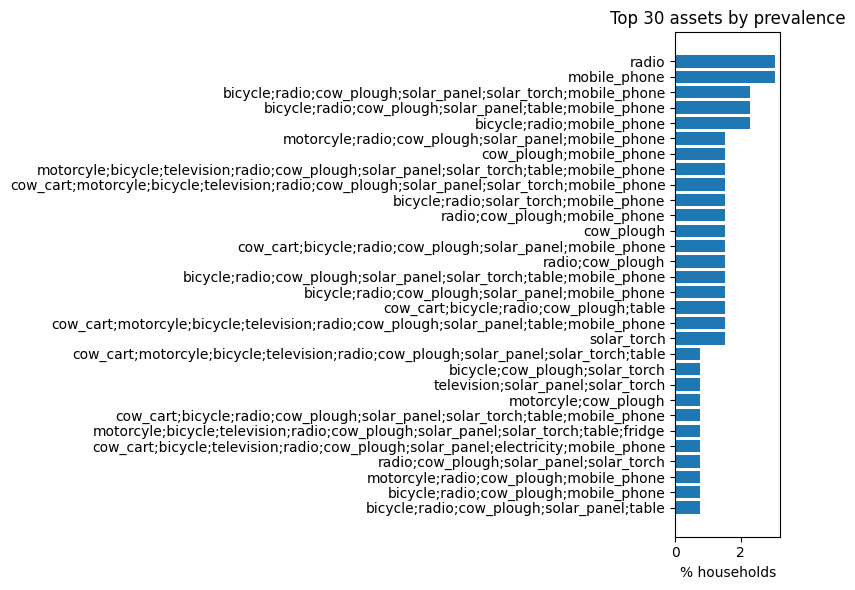

In [27]:
# what features use
# core numeric feature
num_cols = [c for c in ["no_membrs","years_liv","rooms","liv_count","no_meals","num_items","food_shortage_months"] if c in df.columns]

plt.figure(figsize=(10,4))
df[num_cols].plot(kind="box")
plt.title("Core numeric features (boxplot)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# top asset prevalence
all_items = pd.Series([it for sub in df["items_owned_list"] for it in sub])
top_assets_30 = all_items.value_counts().head(30).index.tolist()

prev_30 = pd.Series({
    it: df["items_owned_list"].apply(lambda lst: it in lst).mean()*100
    for it in top_assets_30
}).sort_values()

plt.figure(figsize=(8,6))
plt.barh(prev_30.index, prev_30.values)
plt.xlabel("% households")
plt.title("Top 30 assets by prevalence")
plt.tight_layout()
plt.show()

,TopN,numeric,categorical,binary_assets,total
0,10,7,4,10,21
1,20,7,4,20,31
2,30,7,4,30,41


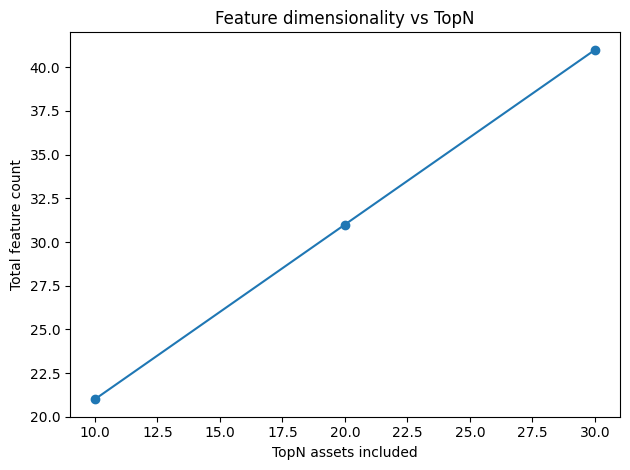

In [29]:
# TopN assets variant overview

def build_features(df_base, topN=20):
    """Return feature matrix components for Gower: scaled numeric, cat codes, binary assets."""
    dfw = df_base.copy()

    numeric_cols = [c for c in ["no_membrs","years_liv","rooms","liv_count","no_meals","num_items","food_shortage_months"] if c in dfw.columns]
    cat_cols = [c for c in ["village","respondent_wall_type","memb_assoc","affect_conflicts"] if c in dfw.columns]

    for c in cat_cols:
        dfw[c] = dfw[c].fillna("missing").astype(str)
    for c in numeric_cols:
        dfw[c] = pd.to_numeric(dfw[c], errors="coerce")
        dfw[c] = dfw[c].fillna(dfw[c].median())

    all_items = pd.Series([it for sub in dfw["items_owned_list"] for it in sub])
    top_assets = all_items.value_counts().head(topN).index.tolist()
    for it in top_assets:
        dfw[f"asset_{it}"] = dfw["items_owned_list"].apply(lambda lst: int(it in lst))
    bin_cols = [f"asset_{it}" for it in top_assets]

    X_num = dfw[numeric_cols].copy()
    mins = X_num.min()
    maxs = X_num.max()
    rng = (maxs - mins).replace(0, 1)
    X_num = (X_num - mins) / rng

    X_cat = pd.DataFrame({c: dfw[c].astype("category").cat.codes for c in cat_cols})

    X_bin = dfw[bin_cols].astype(int)

    meta = {"numeric_cols": numeric_cols, "cat_cols": cat_cols, "bin_cols": bin_cols, "top_assets": top_assets}
    return dfw, X_num, X_cat, X_bin, meta

topN_list = [10, 20, 30]
counts = []
for t in topN_list:
    _, Xn, Xc, Xb, meta = build_features(df, topN=t)
    counts.append({"TopN": t, "numeric": Xn.shape[1], "categorical": Xc.shape[1], "binary_assets": Xb.shape[1], "total": Xn.shape[1]+Xc.shape[1]+Xb.shape[1]})

counts_df = pd.DataFrame(counts)
display(counts_df)

plt.figure()
plt.plot(counts_df["TopN"], counts_df["total"], marker="o")
plt.xlabel("TopN assets included")
plt.ylabel("Total feature count")
plt.title("Feature dimensionality vs TopN")
plt.tight_layout()
plt.show()

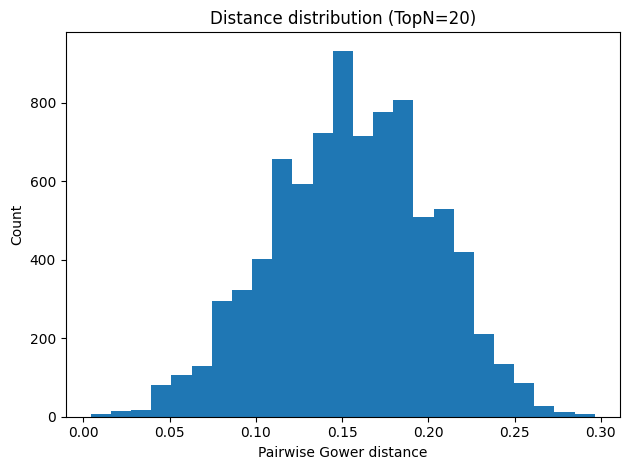

In [31]:
#Gower distance

def gower_distance(X_num, X_cat, X_bin):
    """Pairwise Gower distance matrix using:
       - numeric already scaled [0,1]
       - categorical: mismatch count
       - binary: abs diff
    """
    Xn = X_num.values
    Xc = X_cat.values
    Xb = X_bin.values
    n = Xn.shape[0]
    p = Xn.shape[1] + Xc.shape[1] + Xb.shape[1]
    if p == 0:
        raise ValueError("No features to compute distance.")

    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        dn = np.abs(Xn[i] - Xn).sum(axis=1) if Xn.shape[1] else 0.0
        dc = (Xc[i] != Xc).astype(float).sum(axis=1) if Xc.shape[1] else 0.0
        db = np.abs(Xb[i] - Xb).sum(axis=1) if Xb.shape[1] else 0.0
        D[i] = (dn + dc + db) / p

    D = (D + D.T) / 2
    np.fill_diagonal(D, 0.0)
    return D

dfw20, Xn20, Xc20, Xb20, meta20 = build_features(df, topN=20)
D20 = gower_distance(Xn20, Xc20, Xb20)

upper = D20[np.triu_indices_from(D20, k=1)]
plt.figure()
plt.hist(upper, bins=25)
plt.xlabel("Pairwise Gower distance")
plt.ylabel("Count")
plt.title("Distance distribution (TopN=20)")
plt.tight_layout()
plt.show()

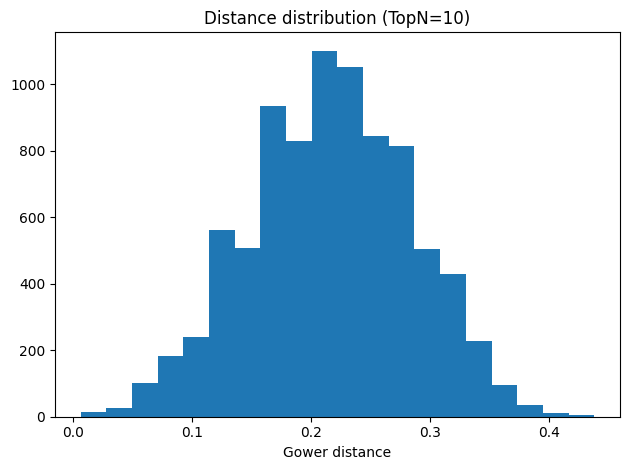

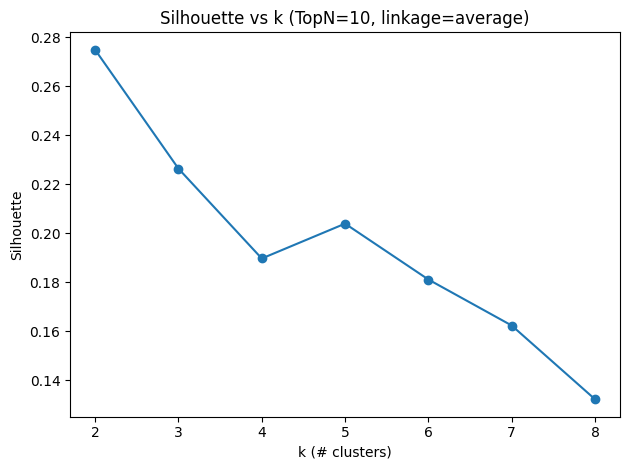

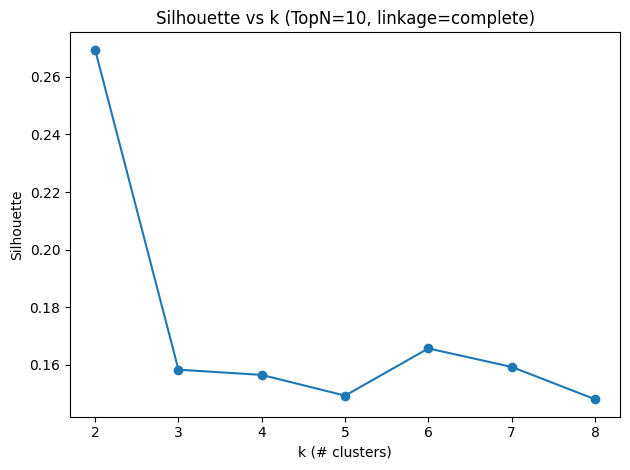

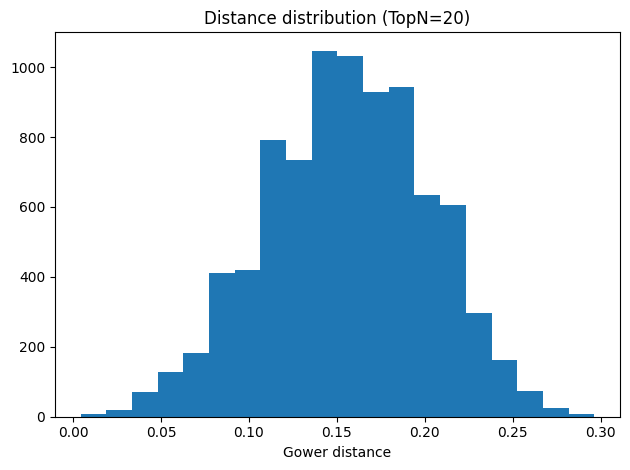

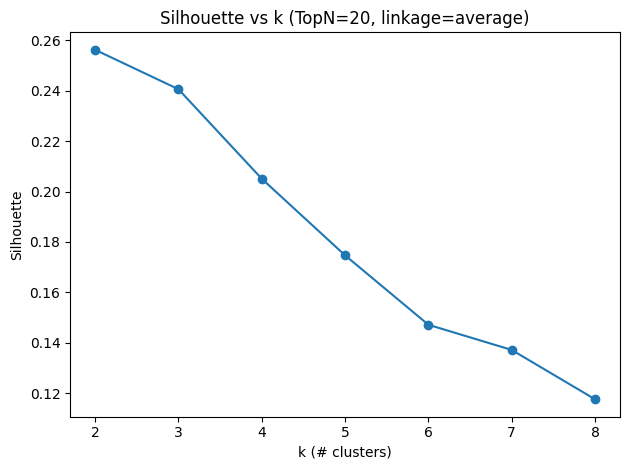

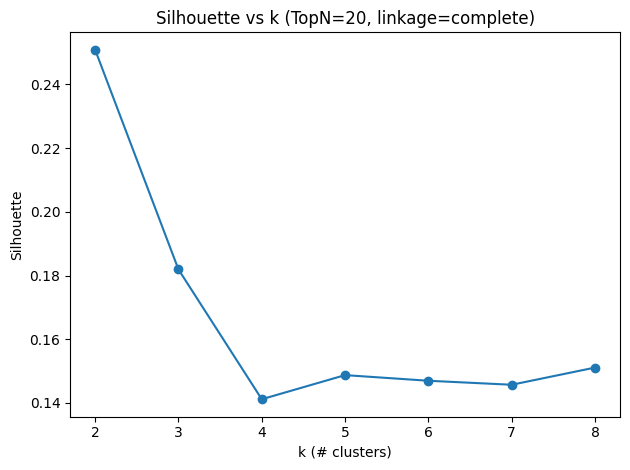

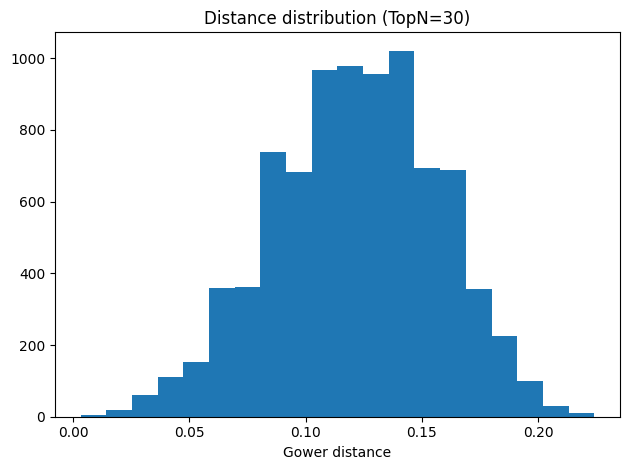

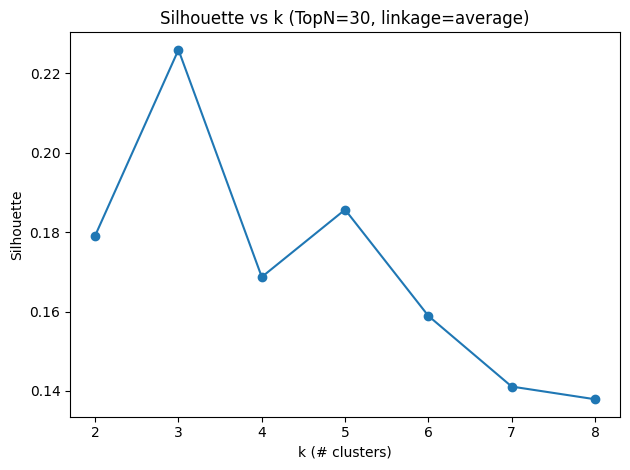

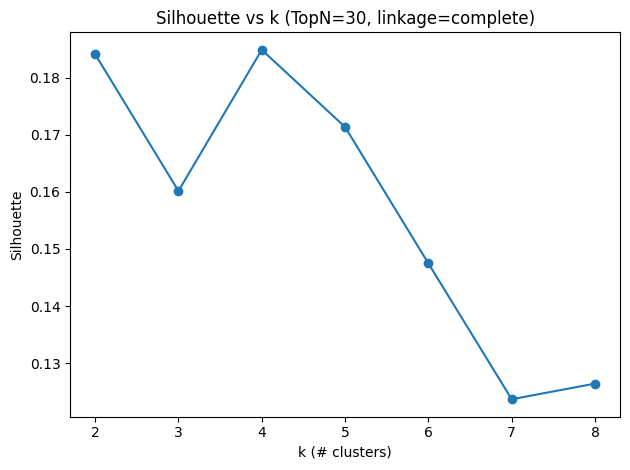

In [38]:
#silhouette curves + dendrogram

def hclust_labels(D, linkage_method="average", k=3):
    Z = linkage(squareform(D, checks=False), method=linkage_method)
    y = fcluster(Z, t=k, criterion="maxclust")
    return Z, y

def silhouette_curve(D, linkage_method, k_list):
    out = []
    Z = linkage(squareform(D, checks=False), method=linkage_method)
    for k in k_list:
        y = fcluster(Z, t=k, criterion="maxclust")
        s = silhouette_score(D, y, metric="precomputed")
        out.append((k, s))
    return pd.DataFrame(out, columns=["k","silhouette"]), Z

topN_list = [10, 20, 30]
linkages = ["average", "complete"]
k_list = list(range(2, 9))

grid_rows = []
Z_store = {}

for topN in topN_list:
    dfw, Xn, Xc, Xb, meta = build_features(df, topN=topN)
    D = gower_distance(Xn, Xc, Xb)

    plt.figure()
    upper = D[np.triu_indices_from(D, k=1)]
    plt.hist(upper, bins=20)
    plt.title(f"Distance distribution (TopN={topN})")
    plt.xlabel("Gower distance")
    plt.tight_layout()
    plt.show()

    for link in linkages:
        curve, Z = silhouette_curve(D, link, k_list)
        Z_store[(topN, link)] = (D, Z, meta, dfw)

        for _, r in curve.iterrows():
            grid_rows.append({"TopN": topN, "linkage": link, "k": int(r["k"]), "silhouette": float(r["silhouette"])})

        plt.figure()
        plt.plot(curve["k"], curve["silhouette"], marker="o")
        plt.xlabel("k (# clusters)")
        plt.ylabel("Silhouette")
        plt.title(f"Silhouette vs k (TopN={topN}, linkage={link})")
        plt.tight_layout()
        plt.show()

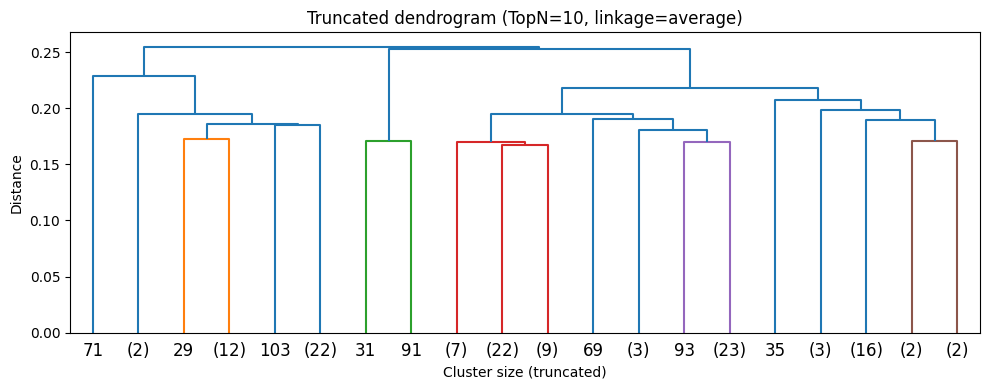

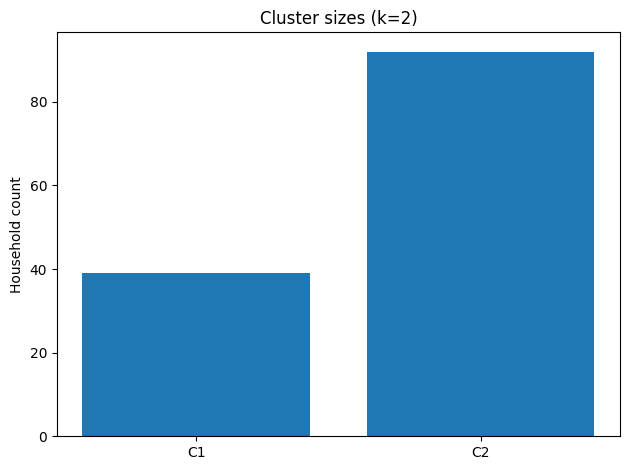

,count
1,39
2,92


In [34]:
# VISUAL: dendrogram for the selected best config + cluster size bar
topN_best = int(best["TopN"])
link_best = str(best["linkage"])
k_best = int(best["k"])

D_best, Z_best, meta_best, dfw_best = Z_store[(topN_best, link_best)]
y_best = fcluster(Z_best, t=k_best, criterion="maxclust")

plt.figure(figsize=(10,4))
dendrogram(Z_best, truncate_mode="lastp", p=20)
plt.title(f"Truncated dendrogram (TopN={topN_best}, linkage={link_best})")
plt.xlabel("Cluster size (truncated)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

sizes = pd.Series(y_best).value_counts().sort_index()
plt.figure()
plt.bar([f"C{i}" for i in sizes.index], sizes.values)
plt.ylabel("Household count")
plt.title(f"Cluster sizes (k={k_best})")
plt.tight_layout()
plt.show()

sizes

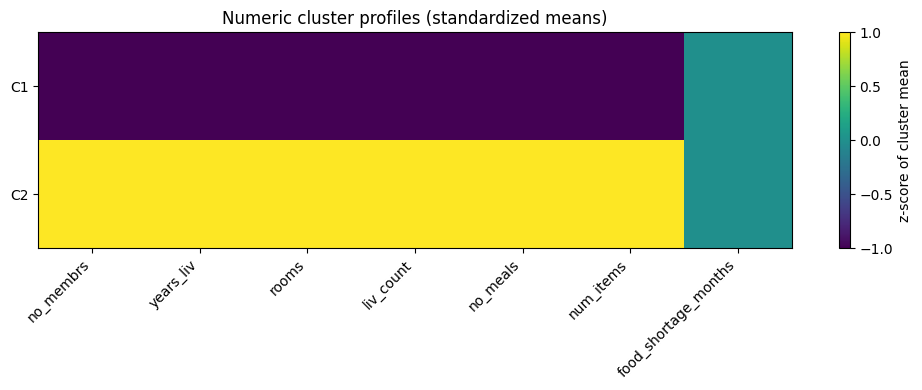

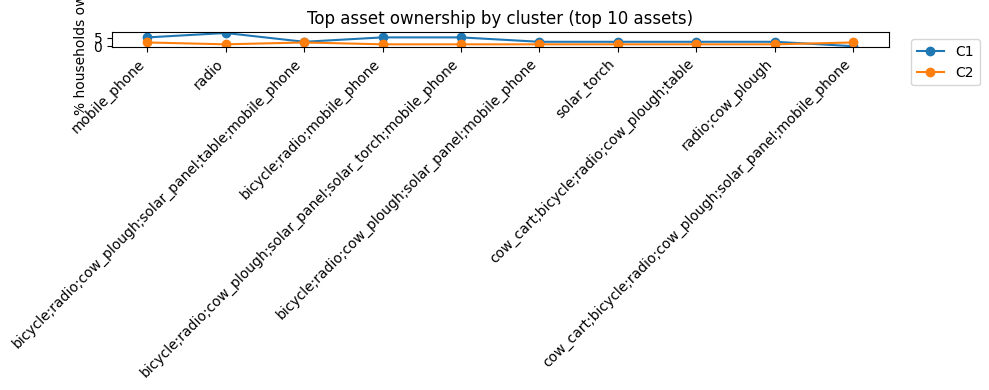

In [37]:
# profiles + village + irrigation

dfp = dfw_best.copy()
dfp["cluster"] = y_best

# heatmap
num_cols = meta_best["numeric_cols"]
num_means = dfp.groupby("cluster")[num_cols].mean()

num_std = (num_means - num_means.mean()) / (num_means.std(ddof=0).replace(0, 1))

plt.figure(figsize=(10,4))
plt.imshow(num_std.values, aspect="auto")
plt.yticks(range(num_std.shape[0]), [f"C{c}" for c in num_std.index])
plt.xticks(range(num_std.shape[1]), num_std.columns, rotation=45, ha="right")
plt.colorbar(label="z-score of cluster mean")
plt.title("Numeric cluster profiles (standardized means)")
plt.tight_layout()
plt.show()

# asset ownership by cluster
asset_cols = meta_best["bin_cols"][:10]
asset_rates = dfp.groupby("cluster")[asset_cols].mean() * 100

plt.figure(figsize=(10,4))
for c in asset_rates.index:
    plt.plot(range(asset_rates.shape[1]), asset_rates.loc[c].values, marker="o", label=f"C{c}")
plt.xticks(range(asset_rates.shape[1]), [a.replace("asset_","") for a in asset_rates.columns], rotation=45, ha="right")
plt.ylabel("% households owning")
plt.title("Top asset ownership by cluster (top 10 assets)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


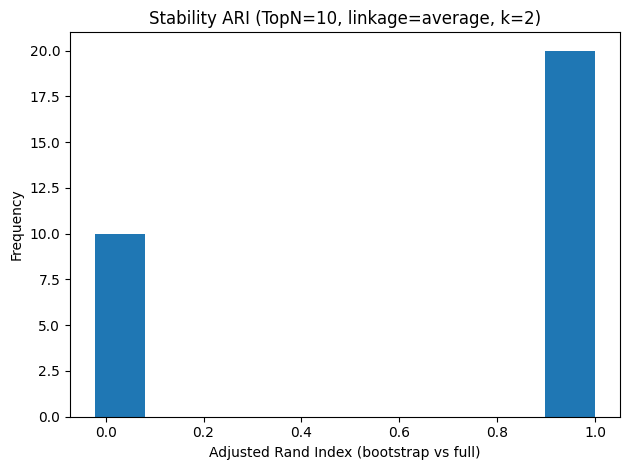

ARI mean: 0.6609977970383781 ARI std: 0.484847764073809


In [42]:
#bootstrap ARI histogram

def bootstrap_ari(df_base, topN, linkage_method, k, B=25, frac=0.8, seed=7):
    rng = np.random.default_rng(seed)

    dfw_full, Xn_full, Xc_full, Xb_full, meta_full = build_features(df_base, topN=topN)
    D_full = gower_distance(Xn_full, Xc_full, Xb_full)
    Z_full = linkage(squareform(D_full, checks=False), method=linkage_method)
    y_full = fcluster(Z_full, t=k, criterion="maxclust")

    aris = []
    n = df_base.shape[0]
    idx_all = np.arange(n)

    for _ in range(B):
        idx = rng.choice(idx_all, size=int(frac*n), replace=False)
        df_b = df_base.iloc[idx].copy()

        dfw_b, Xn_b, Xc_b, Xb_b, meta_b = build_features(df_b, topN=topN)
        D_b = gower_distance(Xn_b, Xc_b, Xb_b)
        Z_b = linkage(squareform(D_b, checks=False), method=linkage_method)
        y_b = fcluster(Z_b, t=k, criterion="maxclust")

        aris.append(adjusted_rand_score(y_full[idx], y_b))

    return np.array(aris)

#ARI histogram
aris_best = bootstrap_ari(df, topN_best, link_best, k_best, B=30, frac=0.8, seed=7)

plt.figure()
plt.hist(aris_best, bins=10)
plt.xlabel("Adjusted Rand Index (bootstrap vs full)")
plt.ylabel("Frequency")
plt.title(f"Stability ARI (TopN={topN_best}, linkage={link_best}, k={k_best})")
plt.tight_layout()
plt.show()

print("ARI mean:", aris_best.mean(), "ARI std:", aris_best.std(ddof=1))